In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from scipy.optimize import curve_fit

In [2]:
df_1_7 = pd.read_csv("output/default.csv")
df_0_5 = pd.read_csv("output/BField_0_5T.csv")
df_1_0 = pd.read_csv("output/BField_1_0T.csv")
df_2_5 = pd.read_csv("output/BField_2_5T.csv")

In [3]:
def gaussian(x, A, x_0, sigma):
    return A * np.exp(-(x - x_0)**2 / (2 * sigma**2))

In [4]:
for i in sorted(df_1_7["Number of Hits"].unique()):
    print(i, len(df_1_7[df_1_7["Number of Hits"] == i].index))

4 121293
5 218154
6 53388
7 22058
8 3666
9 436
10 258
11 71
12 117
13 86
14 67
15 72
16 71
17 45
18 42
19 34
20 57
21 21
22 20
23 20
24 9
25 13
26 22
27 17
28 22
29 18
30 11
31 12
32 9
33 6
34 6
35 3
36 12
37 5
38 7
39 6
40 3
41 8
42 8
43 9
44 2
45 2
46 3
47 3
48 1
49 4
50 2
51 2
52 2
53 2
54 3
55 5
56 4
57 3
58 1
59 5
60 2
62 3
63 2
64 2
66 1
68 1
71 1
75 1


7 200 6
7 700 1
7 7000 2
7 14000 2


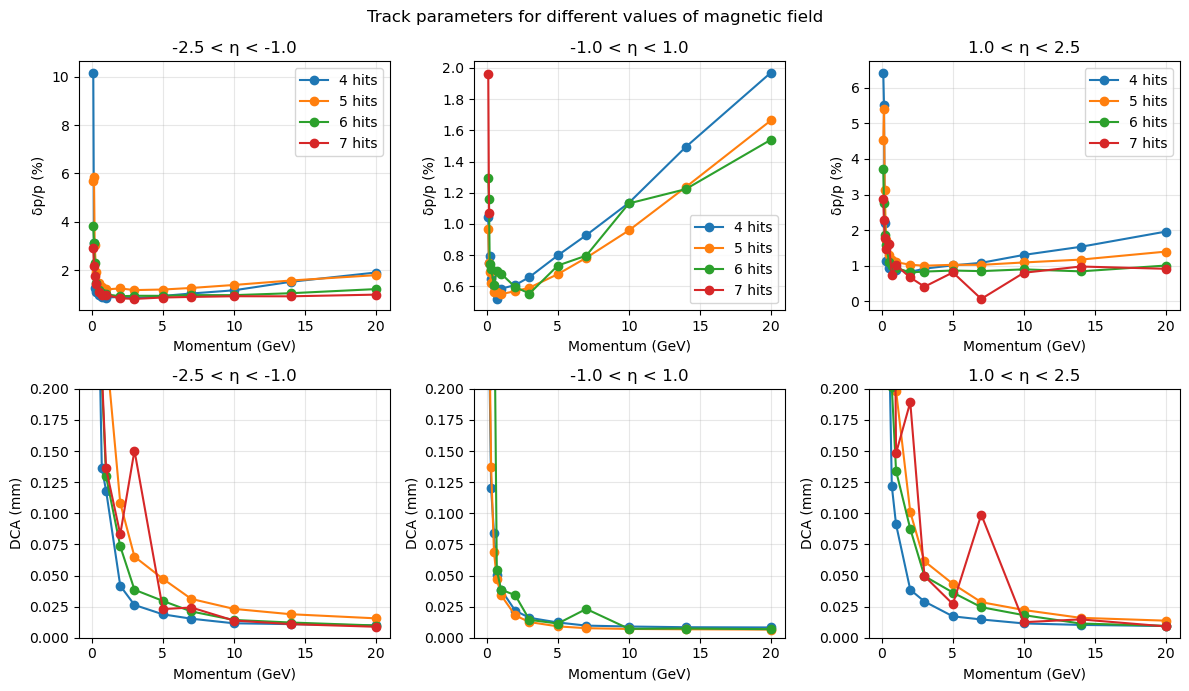

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for numHits in range(4, 8):
    df = df_1_7[df_1_7["Number of Hits"] == numHits]
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                    (df["Pseudorapidity"] < eta_hi)]
        
        momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())
        p_GeV = []
        sigma_delta_pT = []
        mean_DCA = []

        for p in momentum_points[:]:
            subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]
            if (len(subset.index) < 10):
                print(numHits, p, len(subset.index))
                continue
            p_GeV.append(p / 1000)

            pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
            sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
            
            mean = pT_residual.mean() 
            counts, edges = np.histogram(pT_residual, bins=50, range=(mean - 1.5 * sigma_guess, mean + 1.5 * sigma_guess))
            mids = (edges[:-1] + edges[1:]) / 2

            popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), mids[np.argmax(counts)], sigma_guess])
            sigma_delta_pT.append(abs(popt[2]))        

            mean_DCA.append(subset["DCA (mm)"].mean())


        axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, marker="o", label=f"{numHits} hits")
        axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[0, i].set_xlabel("Momentum (GeV)")
        axes[0, i].set_ylabel("δp/p (%)")
        axes[0, i].grid(alpha=0.3)

        axes[1, i].plot(p_GeV, mean_DCA, marker="o", label=f"{numHits} hits")
        axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[1, i].set_xlabel("Momentum (GeV)")
        axes[1, i].set_ylabel("DCA (mm)")
        axes[1, i].grid(alpha=0.3)
        axes[1, i].set_ylim(0, 0.2)

for i in range(3):
    axes[0, i].legend()

plt.suptitle("Track parameters for different values of magnetic field")
plt.tight_layout()
plt.show()

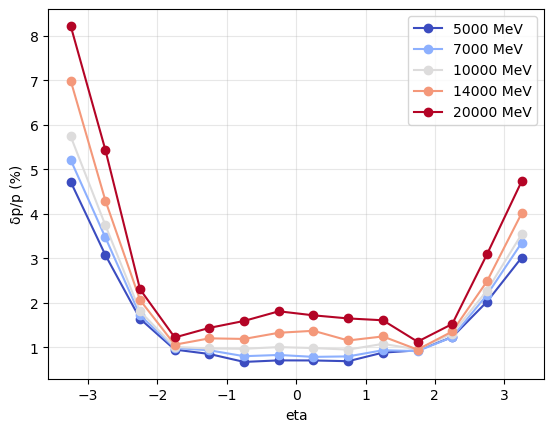

In [ ]:
momentum_points = sorted(df_1_7["True Momentum (MeV/c)"].unique())

cmap = plt.colormaps['coolwarm']

for i, p in enumerate(momentum_points[-5::]):
    etas = []
    sigma_delta_pT = []
    mean_DCA = []
    df = df_1_7[df_1_7["True Momentum (MeV/c)"] == p]
    for eta_lo in np.arange(-3.5, 3.5, 0.5):
        eta_hi = eta_lo + 0.5
        subset = df[(df["Pseudorapidity"] >= eta_lo) &
                    (df["Pseudorapidity"] < eta_hi)]

        if (len(subset.index) < 10):
            print(numHits, p, len(subset.index))
            continue
        pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
        sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
        
        mean = pT_residual.mean() 
        counts, edges = np.histogram(pT_residual, bins=50, range=(mean - 1.5 * sigma_guess, mean + 1.5 * sigma_guess))
        mids = (edges[:-1] + edges[1:]) / 2

        popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), mids[np.argmax(counts)], sigma_guess])
        sigma_delta_pT.append(abs(popt[2]))     

        mean_DCA.append(subset["DCA (mm)"].mean())

        etas.append((eta_lo + eta_hi) / 2)

    color = cmap(i / 4)
    plt.plot(etas, np.array(sigma_delta_pT) * 100, marker="o", color=color, label=f"{p} MeV")

plt.xlabel("eta")
plt.ylabel("δp/p (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

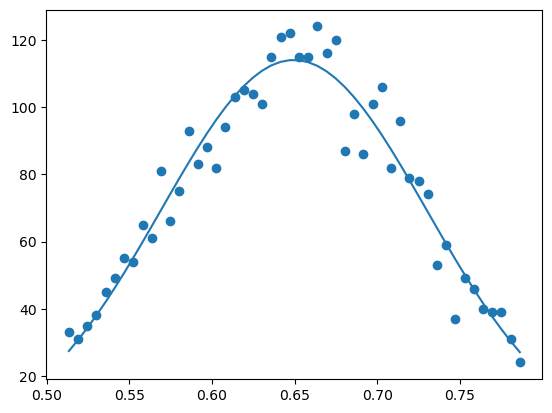

In [97]:
eta_low = 1
eta_high = 2
df_eta = df_1_0[(df_1_0["Pseudorapidity"] >= eta_lo) &
            (df_1_0["Pseudorapidity"] < eta_hi)]

subset = df_eta[df_eta["True Momentum (MeV/c)"] == 100]

pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]

sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2

mean = pT_residual.mean() 
counts, edges = np.histogram(pT_residual, bins=50, range=(mean - 1.5 * sigma_guess, mean + 1.5 * sigma_guess))
mids = (edges[:-1] + edges[1:]) / 2

popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), mids[np.argmax(counts)], sigma_guess])
sigma_delta_pT.append(abs(popt[2]))   

plt.scatter(mids, counts)
plt.plot(mids, gaussian(mids, *popt))

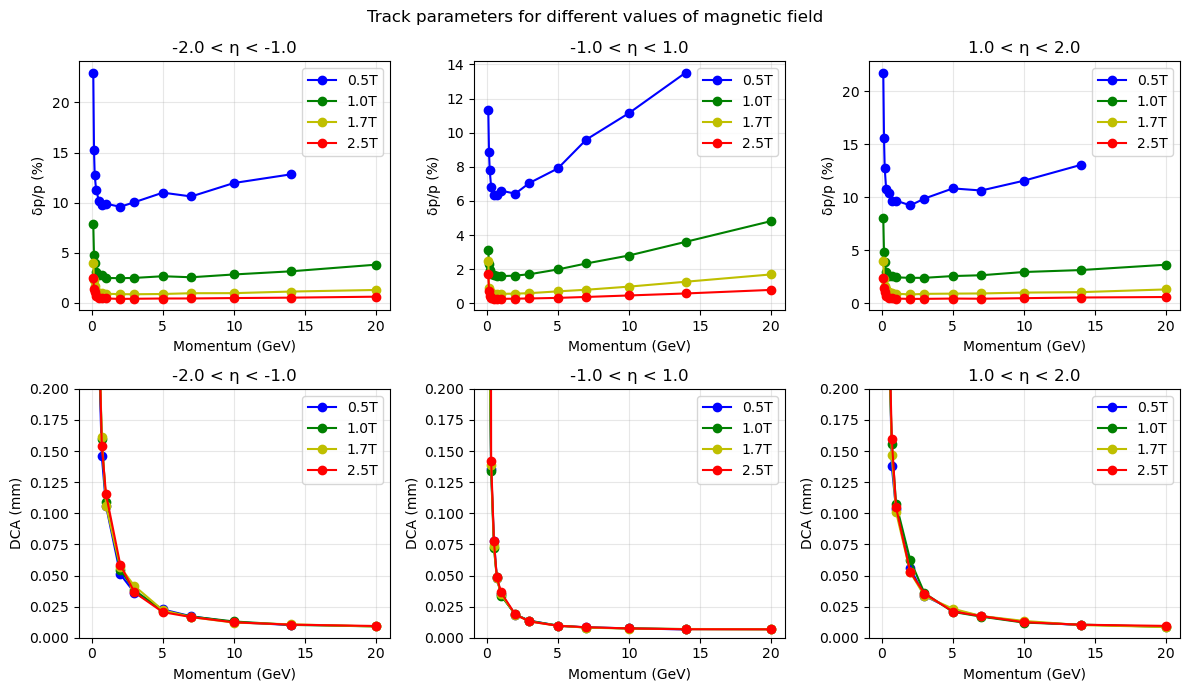

In [99]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.0, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.0),
]

dataframes = {0.5: df_0_5, 1.0: df_1_0, 1.7: df_1_7, 2.5: df_2_5}
colors = {0.5: "b", 1.0: "g", 1.7: "y", 2.5: "r"}

for B, df in dataframes.items():
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                    (df["Pseudorapidity"] < eta_hi)]
        
        momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())
        p_GeV = []
        sigma_delta_pT = []
        mean_DCA = []

        for p in momentum_points[:]:
            subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]
            if len(subset) < 20:
                continue

            pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
            sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
            
            mean = pT_residual.mean() 
            counts, edges = np.histogram(pT_residual, bins=50, range=(mean - 1.5 * sigma_guess, mean + 1.5 * sigma_guess))
            mids = (edges[:-1] + edges[1:]) / 2

            popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), mids[np.argmax(counts)], sigma_guess])
            sigma_delta_pT.append(abs(popt[2]))     

            p_GeV.append(p / 1000)

            mean_DCA.append(subset["DCA (mm)"].mean())


        axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, color=colors[B], marker="o", label=f"{B}T")
        axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[0, i].set_xlabel("Momentum (GeV)")
        axes[0, i].set_ylabel("δp/p (%)")
        axes[0, i].grid(alpha=0.3)

        axes[1, i].plot(p_GeV, mean_DCA, color=colors[B], marker="o", label=f"{B}T")
        axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[1, i].set_xlabel("Momentum (GeV)")
        axes[1, i].set_ylabel("DCA (mm)")
        axes[1, i].grid(alpha=0.3)
        axes[1, i].set_ylim(0, 0.2)

for i in range(3):
    axes[0, i].legend()
    axes[1, i].legend()

plt.suptitle("Track parameters for different values of magnetic field")
plt.tight_layout()
plt.show()

In [17]:
df_7um = pd.read_csv("output/default.csv")
df_3um = pd.read_csv("output/resolution_3um.csv")
df_15um = pd.read_csv("output/resolution_15um.csv")
df_25um = pd.read_csv("output/resolution_25um.csv")

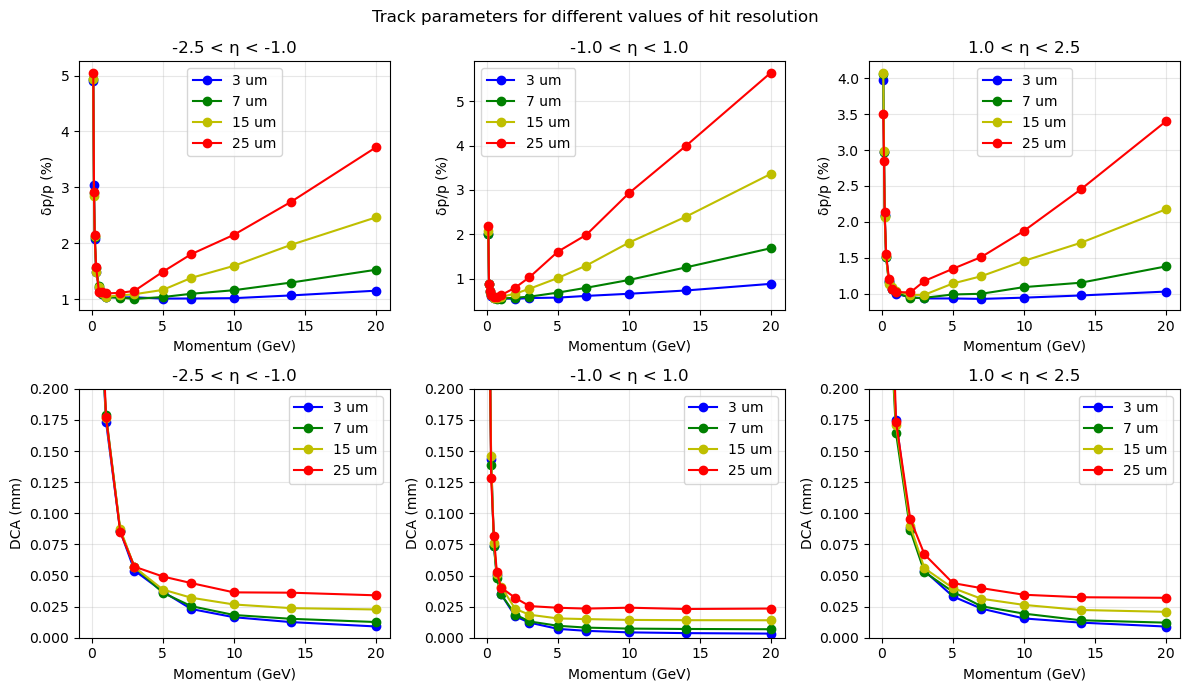

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

dataframes = {3: df_3um, 7: df_7um, 15: df_15um, 25: df_25um}
colors = {3: "b", 7: "g", 15: "y", 25: "r"}

for res, df in dataframes.items():
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                    (df["Pseudorapidity"] < eta_hi)]
        
        momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())
        p_GeV = []
        sigma_delta_pT = []
        mean_DCA = []

        for p in momentum_points[:]:
            subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]
            p_GeV.append(p / 1000)

            pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
            sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
            
            mean = pT_residual.mean() 
            counts, edges = np.histogram(pT_residual, bins=50, range=(mean - 1.5 * sigma_guess, mean + 1.5 * sigma_guess))
            mids = (edges[:-1] + edges[1:]) / 2

            popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), mids[np.argmax(counts)], sigma_guess])
            sigma_delta_pT.append(abs(popt[2]))        

            mean_DCA.append(subset["DCA (mm)"].mean())


        axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, color=colors[res], marker="o", label=f"{res} um")
        axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[0, i].set_xlabel("Momentum (GeV)")
        axes[0, i].set_ylabel("δp/p (%)")
        axes[0, i].grid(alpha=0.3)

        axes[1, i].plot(p_GeV, mean_DCA, color=colors[res], marker="o", label=f"{res} um")
        axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[1, i].set_xlabel("Momentum (GeV)")
        axes[1, i].set_ylabel("DCA (mm)")
        axes[1, i].grid(alpha=0.3)
        axes[1, i].set_ylim(0, 0.2)

for i in range(3):
    axes[0, i].legend()
    axes[1, i].legend()

plt.suptitle("Track parameters for different values of hit resolution")
plt.tight_layout()
plt.show()

In [21]:
df_mat_x1 = pd.read_csv("output/default.csv")
df_mat_x2 = pd.read_csv("output/material_x2.csv")
df_mat_x3 = pd.read_csv("output/material_x3.csv")
df_mat_x4 = pd.read_csv("output/material_x4.csv")

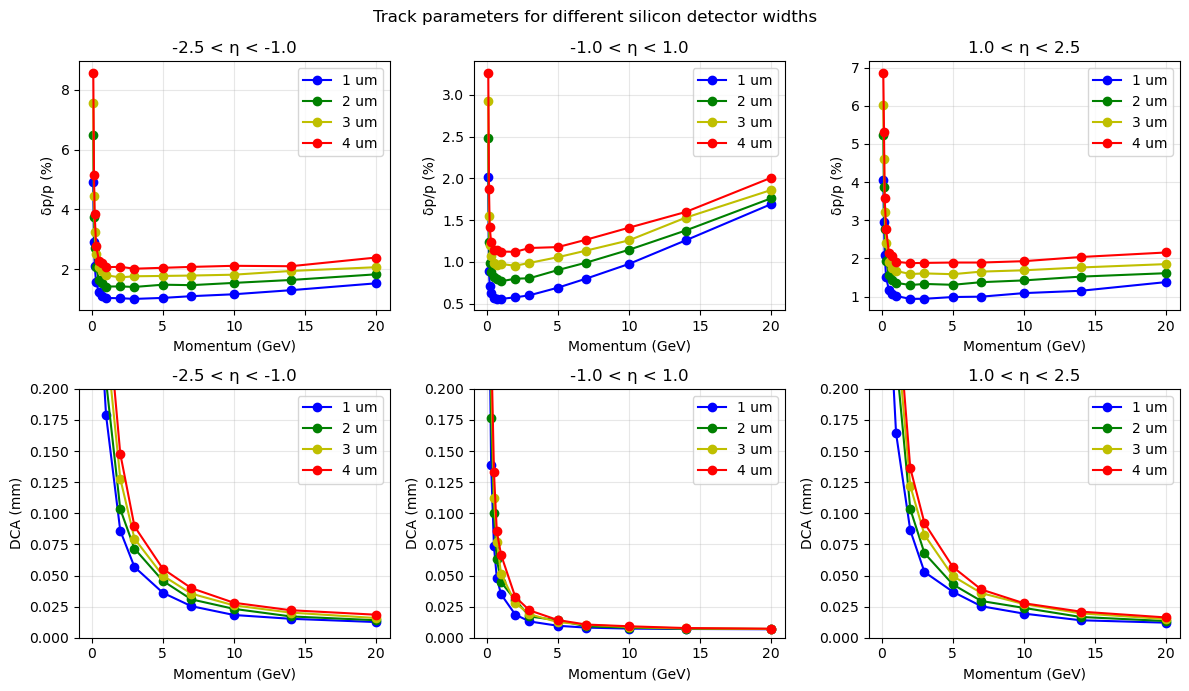

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

dataframes = {1: df_mat_x1, 2: df_mat_x2, 3: df_mat_x3, 4: df_mat_x4}
colors = {1: "b", 2: "g", 3: "y", 4: "r"}

for width, df in dataframes.items():
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                    (df["Pseudorapidity"] < eta_hi)]
        
        momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())
        p_GeV = []
        sigma_delta_pT = []
        mean_DCA = []

        for p in momentum_points[:]:
            subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]
            p_GeV.append(p / 1000)

            pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
            sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
            
            counts, edges = np.histogram(pT_residual, bins=50, range=(-sigma_guess * 2, sigma_guess * 2))
            mids = (edges[:-1] + edges[1:]) / 2

            popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), 0, sigma_guess])
            sigma_delta_pT.append(abs(popt[2]))     

            mean_DCA.append(subset["DCA (mm)"].mean())


        axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, color=colors[width], marker="o", label=f"{width} um")
        axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[0, i].set_xlabel("Momentum (GeV)")
        axes[0, i].set_ylabel("δp/p (%)")
        axes[0, i].grid(alpha=0.3)

        axes[1, i].plot(p_GeV, mean_DCA, color=colors[width], marker="o", label=f"{width} um")
        axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[1, i].set_xlabel("Momentum (GeV)")
        axes[1, i].set_ylabel("DCA (mm)")
        axes[1, i].grid(alpha=0.3)
        axes[1, i].set_ylim(0, 0.2)

for i in range(3):
    axes[0, i].legend()
    axes[1, i].legend()

plt.suptitle("Track parameters for different silicon detector widths")
plt.tight_layout()
plt.show()

In [25]:
df_pion = pd.read_csv("output/default.csv")
df_positron = pd.read_csv("output/gun_positrons.csv")
df_proton = pd.read_csv("output/gun_protons.csv")
df_kaon = pd.read_csv("output/gun_kaons.csv")

/Users/parkinpham/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


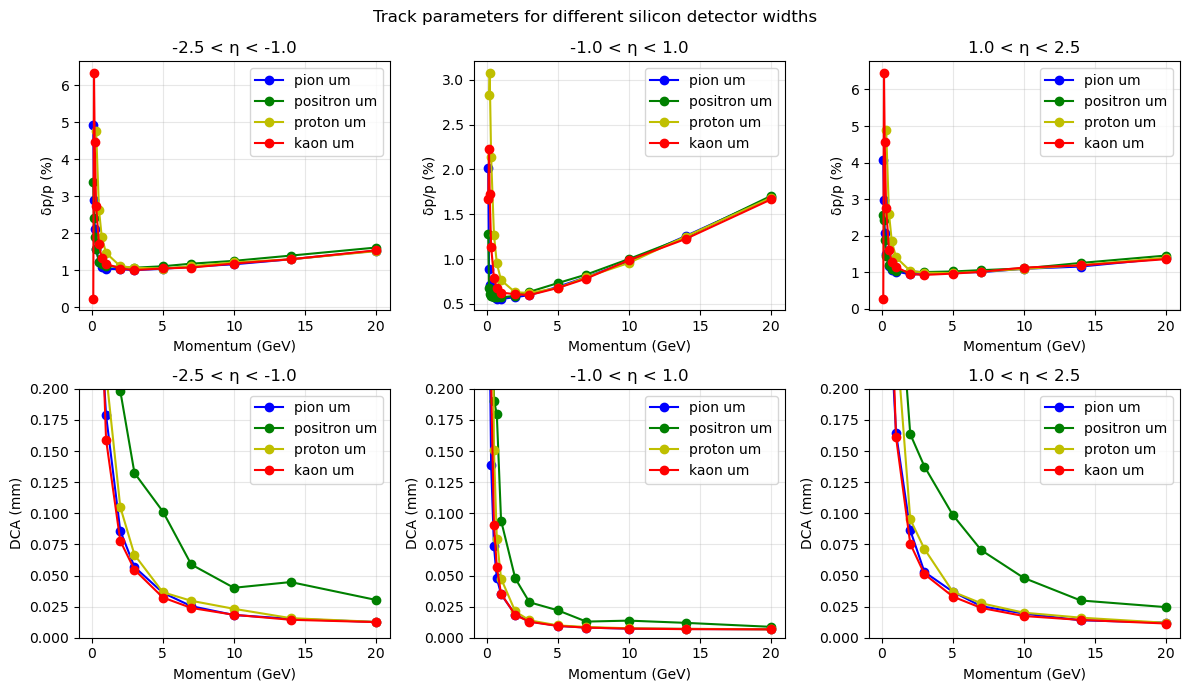

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

dataframes = {"pion": df_pion, "positron": df_positron, "proton": df_proton, "kaon": df_kaon}
colors = {"pion": "b", "positron": "g", "proton": "y", "kaon": "r"}

for width, df in dataframes.items():
    for i, (eta_lo, eta_hi) in enumerate(eta_bins):
        df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                    (df["Pseudorapidity"] < eta_hi)]
        
        momentum_points = sorted(df_eta["True Momentum (MeV/c)"].unique())
        p_GeV = []
        sigma_delta_pT = []
        mean_DCA = []

        for p in momentum_points[:]:
            subset = df_eta[df_eta["True Momentum (MeV/c)"] == p]

            pT_residual = (subset["Fitted Transverse Momentum (MeV/c)"] - subset["True Transverse Momentum (MeV/c)"]) / subset["True Transverse Momentum (MeV/c)"]
            sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2
            
            counts, edges = np.histogram(pT_residual, bins=50, range=(-sigma_guess * 2, sigma_guess * 2))
            mids = (edges[:-1] + edges[1:]) / 2
            try:
                popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), 0, sigma_guess])
                sigma_delta_pT.append(abs(popt[2]))     

                mean_DCA.append(subset["DCA (mm)"].mean())
            except:
                continue
            p_GeV.append(p / 1000)


        axes[0, i].plot(p_GeV, np.array(sigma_delta_pT) * 100, color=colors[width], marker="o", label=f"{width} um")
        axes[0, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[0, i].set_xlabel("Momentum (GeV)")
        axes[0, i].set_ylabel("δp/p (%)")
        axes[0, i].grid(alpha=0.3)

        axes[1, i].plot(p_GeV, mean_DCA, color=colors[width], marker="o", label=f"{width} um")
        axes[1, i].set_title(f"{eta_lo} < η < {eta_hi}")
        axes[1, i].set_xlabel("Momentum (GeV)")
        axes[1, i].set_ylabel("DCA (mm)")
        axes[1, i].grid(alpha=0.3)
        axes[1, i].set_ylim(0, 0.2)

for i in range(3):
    axes[0, i].legend()
    axes[1, i].legend()

plt.suptitle("Track parameters for different silicon detector widths")
plt.tight_layout()
plt.show()